In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화 

In [2]:
import random 
import numpy as np 
import matplotlib.pyplot as plt 

In [8]:
random.randint(160, 195)

189

In [11]:
data = []
for i in range(50):
    print(i)
    #여자데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])    
    #남자 데이터 (몸무게와 키) 추가 
    data.append([random.randint(60, 95), random.randint(160, 195)])    


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [18]:
print('여자 몸무게(x축):', [female[0] for female in data[::2]])
print('여자 키(y축):', [female[1] for female in data[::2]])

print('남자 몸무게(x축):', [male[0] for male in data[1::2]])
print('남자 키(y축):', [male[1] for male in data[1::2]])

여자 몸무게(x축): [40, 64, 60, 46, 67, 61, 65, 55, 54, 40, 50, 55, 65, 62, 50, 51, 64, 47, 41, 58, 62, 46, 65, 62, 64, 65, 53, 55, 59, 65, 70, 49, 48, 56, 42, 62, 64, 58, 50, 56, 54, 42, 42, 55, 69, 51, 46, 69, 45, 70]
여자 키(y축): [158, 150, 150, 167, 161, 151, 150, 157, 150, 148, 143, 163, 143, 150, 145, 161, 147, 144, 165, 142, 153, 157, 169, 154, 156, 155, 148, 143, 166, 163, 152, 142, 150, 153, 161, 154, 159, 160, 164, 149, 140, 168, 167, 151, 151, 152, 169, 170, 147, 162]
남자 몸무게(x축): [88, 92, 93, 60, 70, 92, 73, 60, 91, 69, 81, 78, 83, 66, 69, 89, 95, 85, 85, 92, 89, 81, 73, 91, 93, 63, 79, 63, 81, 93, 85, 61, 89, 94, 78, 95, 61, 84, 81, 80, 77, 94, 80, 74, 80, 61, 92, 95, 84, 61]
남자 키(y축): [180, 171, 167, 185, 166, 177, 181, 167, 195, 177, 165, 163, 179, 172, 177, 184, 167, 167, 169, 175, 185, 160, 177, 165, 172, 183, 178, 191, 175, 175, 190, 192, 166, 189, 174, 192, 186, 181, 163, 190, 176, 176, 174, 166, 190, 179, 192, 187, 176, 165]


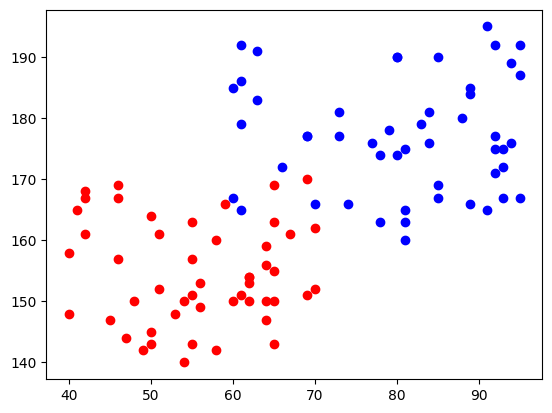

In [21]:
plt.plot([female[0] for female in data [::2]],
         [female[1] for female in data [::2]], 'o', color='r')

plt.plot([male[0] for male in data [1::2]],
         [male[1] for male in data [1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직 

In [28]:
# 초기 랜덤 지점 2개 
random_points=[
    [random.randint(40,90), random.randint(140, 195)], 
    [random.randint(40,90), random.randint(140, 195)]
]
random_points[0], random_points[1]

([89, 160], [47, 155])

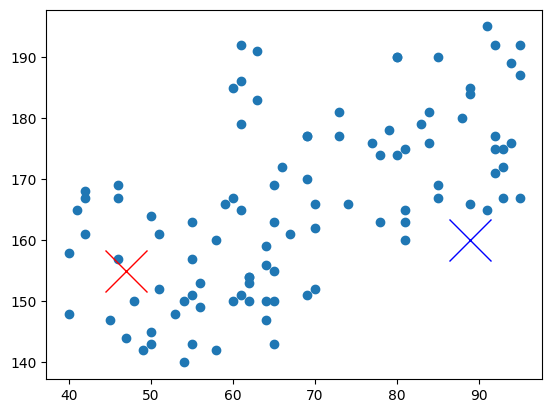

In [34]:
plt.plot([d[0] for d in data], 
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b') #기준점0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')# 기준점1

In [36]:
# 두점 거리를 return 하는 함수 점은 [50,160]
def dist (a,b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2)
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [37]:
# random_points[0]에 가까운 그룹 (group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(45, 55)

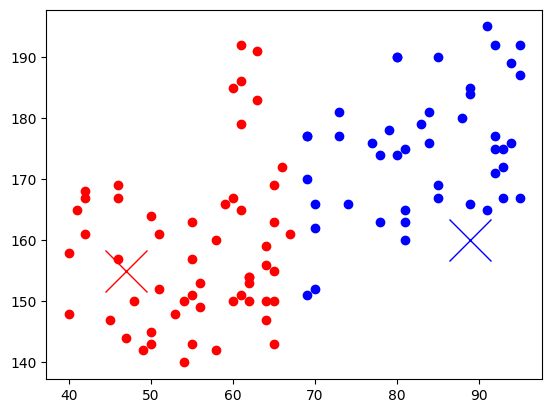

In [39]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for  d in group0], [d[1] for d in group0],'o', color='b')
plt.plot([d[0] for  d in group1], [d[1] for d in group1],'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [54]:
# group0과 group1 중심점으로 기준점을 이용 
group0_meanX=np.mean([d[0] for d in group0])
group0_meanY=np.mean([d[1] for d in group0])
random_points[0]=[group0_meanX, group0_meanY]

group1_meanX=np.mean([d[0] for d in group1])
group1_meanY=np.mean([d[1] for d in group1])
random_points[1]=[group1_meanX, group1_meanY]

random_points

[[83.22222222222223, 174.75555555555556],
 [55.763636363636365, 158.45454545454547]]

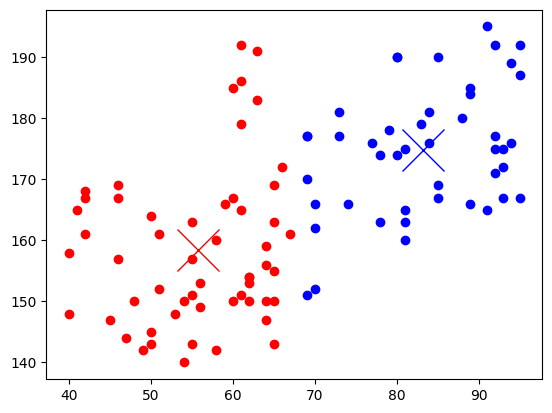

In [52]:
plt.plot([d[0] for  d in group0], [d[1] for d in group0],'o', color='b')
plt.plot([d[0] for  d in group1], [d[1] for d in group1],'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()